# 0. Getting setup

In [2]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) == 2, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


In [3]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4400 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 43.88 MiB/s, done.
Resolving deltas: 100% (2661/2661), done.
Updating files: 100% (248/248), done.


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# 1. Get Data

In [5]:
!pip install -q kagglehub

In [6]:
import kagglehub
from pathlib import Path

DATA_DIR = Path("/content/picksense/data/raw/openloris")
DATA_DIR.mkdir(parents=True, exist_ok=True)

path = kagglehub.dataset_download(
    "zhedamai/openlorisobject",
    output_dir=str(DATA_DIR)
)

print("Downloaded to:")
print(path)

100%|██████████| 18.2G/18.2G [03:38<00:00, 89.7MB/s]

Extracting files...


Downloaded to:
/content/picksense/data/raw/openloris


In [7]:
# Check if the dataset folder exists and list its contents
print("Dataset folder exists:", DATA_DIR.exists())

for item in DATA_DIR.iterdir():
    print(item.name)

Dataset folder exists: True
openloris
.complete


In [8]:
# List the first 100 files in the dataset directory
count = 0

for item in DATA_DIR.rglob("*"):
    print(item.relative_to(DATA_DIR))

    count += 1
    if count == 100:
        break

openloris
.complete
openloris/occlusion
openloris/illumination
openloris/pixel
openloris/clutter
openloris/sequence
.complete/datasets
openloris/occlusion/test
openloris/occlusion/train
openloris/illumination/test
openloris/illumination/train
openloris/pixel/test
openloris/pixel/train
openloris/clutter/test
openloris/clutter/train
openloris/sequence/test
openloris/sequence/validation
openloris/sequence/train
openloris/occlusion/test/task2
openloris/occlusion/test/task8
openloris/occlusion/test/task9
openloris/occlusion/test/task1
openloris/occlusion/test/task7
openloris/occlusion/test/task4
openloris/occlusion/test/note
openloris/occlusion/test/task6
openloris/occlusion/test/task3
openloris/occlusion/test/task5
openloris/occlusion/train/task2
openloris/occlusion/train/task8
openloris/occlusion/train/task9
openloris/occlusion/train/task1
openloris/occlusion/train/task7
openloris/occlusion/train/task4
openloris/occlusion/train/note
openloris/occlusion/train/task6
openloris/occlusion/trai

In [9]:
from pathlib import Path

DATASET_DIR = Path(path)   # path returned by kagglehub

image_extensions = {".jpg", ".jpeg", ".png"}

images = [
    p for p in DATASET_DIR.rglob("*")
    if p.suffix.lower() in image_extensions
]

print("Number of image files found:", len(images))

print("\nFirst 10 images:")
for img_path in images[:10]:
    print(img_path)

Number of image files found: 404060

First 10 images:
/content/picksense/data/raw/openloris/openloris/occlusion/test/task2/bowl_01/frame0174.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/test/task2/bowl_01/frame0153.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/test/task2/bowl_01/frame0192.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/test/task2/bowl_01/frame0145.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/test/task2/bowl_01/frame0227.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/test/task2/bowl_01/frame0220.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/test/task2/bowl_01/frame0035.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/test/task2/bowl_01/frame0209.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/test/task2/toy_04/frame0228.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/test/task2/toy_04/frame0180.jpg


Image path: /content/picksense/data/raw/openloris/openloris/occlusion/test/task2/bowl_01/frame0174.jpg
Image size: (424, 240)


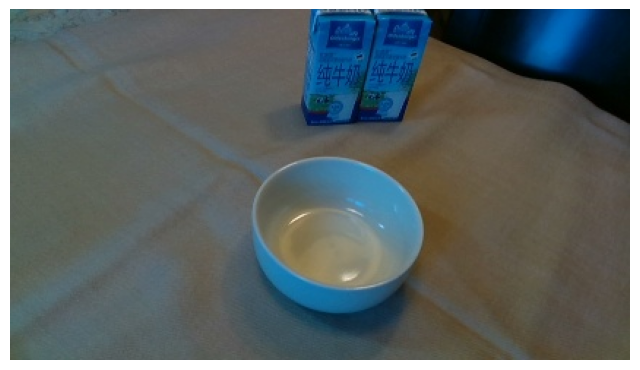

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = images[0]

img = Image.open(img_path)

print("Image path:", img_path)
print("Image size:", img.size)

plt.figure(figsize=(8, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [11]:
import os, shutil
from pathlib import Path

# --- locate OpenLORIS occlusion root (handles nested openloris/openloris) ---
BASE = Path("/content/picksense/data/raw/openloris")
OCC = [p for p in BASE.rglob("occlusion") if p.is_dir()][0]
print("occlusion source:", OCC)

# --- 9 difficulty-ordered tasks -> occlusion % -> pickability label ---
TASK_TO_LABEL = {
    "task1": "accessible",   "task2": "accessible",   "task3": "accessible",    # 0%
    "task4": "partial",      "task5": "partial",      "task6": "partial",       # 25%
    "task7": "inaccessible", "task8": "inaccessible", "task9": "inaccessible",   # 50%
}
CLASSES = ["accessible", "partial", "inaccessible"]

image_path = Path("/content/picksense/data/pickability_occlusion")
USE_SYMLINKS = True  # fast, no extra disk

def build_split(split):
    made = {c: 0 for c in CLASSES}
    for task_dir in sorted(p for p in (OCC / split).iterdir() if p.is_dir()):
        label = TASK_TO_LABEL.get(task_dir.name)
        if label is None:
            continue
        out_dir = image_path / split / label
        out_dir.mkdir(parents=True, exist_ok=True)
        for inst_dir in sorted(p for p in task_dir.iterdir() if p.is_dir()):
            for img in inst_dir.glob("*.jpg"):
                link = out_dir / f"{task_dir.name}__{inst_dir.name}__{img.name}"
                if link.exists() or link.is_symlink():
                    continue
                if USE_SYMLINKS:
                    os.symlink(img.resolve(), link)
                else:
                    shutil.copy2(img, link)
                made[label] += 1
    return made

if image_path.exists():
    shutil.rmtree(image_path)   # fresh build so counts are exact

for split in ["train", "test"]:
    counts = build_split(split)
    print(f"[{split}] linked:", counts, "total:", sum(counts.values()))

# --- FoodVision-style paths ---
train_dir = image_path / "train"
test_dir  = image_path / "test"
print("\nimage_path:", image_path)
print("train_dir :", train_dir)
print("test_dir  :", test_dir)

occlusion source: /content/picksense/data/raw/openloris/openloris/occlusion
[train] linked: {'accessible': 14008, 'partial': 14214, 'inaccessible': 14008} total: 42230
[test] linked: {'accessible': 1632, 'partial': 1656, 'inaccessible': 1632} total: 4920

image_path: /content/picksense/data/pickability_occlusion
train_dir : /content/picksense/data/pickability_occlusion/train
test_dir  : /content/picksense/data/pickability_occlusion/test


In [12]:
from torchvision import datasets
train_data = datasets.ImageFolder(train_dir)
test_data  = datasets.ImageFolder(test_dir)
print("classes:", train_data.classes)
print("train:", len(train_data), "| test:", len(test_data))
print("per-class train:", {c: train_data.targets.count(i) for i, c in enumerate(train_data.classes)})
print("per-class test:", {c: test_data.targets.count(i) for i, c in enumerate(test_data.classes)})

classes: ['accessible', 'inaccessible', 'partial']
train: 42230 | test: 4920
per-class train: {'accessible': 14008, 'inaccessible': 14008, 'partial': 14214}
per-class test: {'accessible': 1632, 'inaccessible': 1632, 'partial': 1656}


# 2. Create Datasets and DataLoaders

### 2.1 Prepare transforms for images


In [13]:
# Create image size (from Table 3 in the ViT paper)
IMG_SIZE = 224

import torchvision.transforms as transforms
# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


### 2.2 Turn images into DataLoader's
Transforms created!

Let's now create our DataLoader's.

The ViT paper states the use of a batch size of 4096 which is 128x the size of the batch size we've been using (32).

However, we're going to stick with a batch size of 32.

In [15]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

len(train_dataloader), len(test_dataloader), class_names

(1320, 154, ['accessible', 'inaccessible', 'partial'])

### 2.3 Visualize a single image

In [22]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(1))

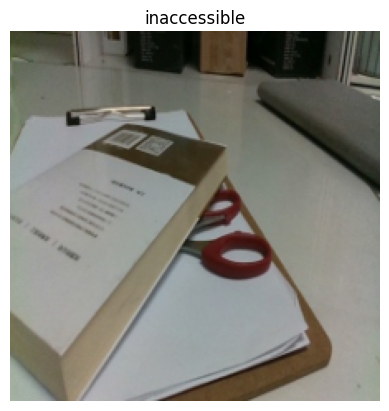

In [23]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

# 3. Replicating the ViT paper: an overview

Looking at a whole machine learning paper can be overwhelming, especially if it's a new architecture or model. To make it easier to understand, let's break down the ViT paper into its core components.

* **inputs** - What goes into the model (e.g. images, text, audio, etc.)
* **outputs** - What comes out the model/layer/block? (in this case, i want the model to output classification labels)
* **layers** - Takes an inputs, manipulates it with a function(e.g could be self-attention)
* **blocks** - A collection of layers.
* **model** - A collection of blocks.

### 3.1 ViT overview: pieces of the puzzle

* firgure 1 : Visual overview of the architecture of the Vision Transformer (ViT) model. The model takes an image as input, splits it into patches, and then processes these patches through a series of transformer blocks to produce a final classification output.
* Four equations: math equations which define the functions of each layer/block.
* Table 1/3: different hyperparameters for the architecture/training.
* Text: description of the architecture and training process.

#### Figure 1
 ![](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-figure-1-architecture-overview.png?raw=true)

* Embedding = learnable representations (startt with random numbers and improve them over time)

#### Four equations

![](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-four-equations.png?raw=true)

## * Section 3.1  describe the various equations:



**Equation 1:** 

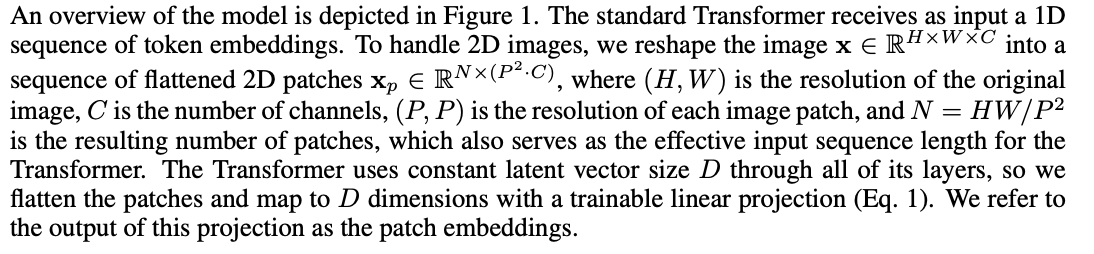

**Equation 1:** 

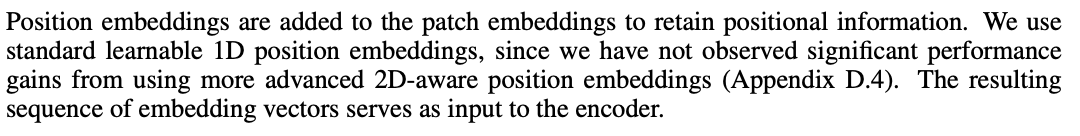

**Equations 2 & 3 :** 

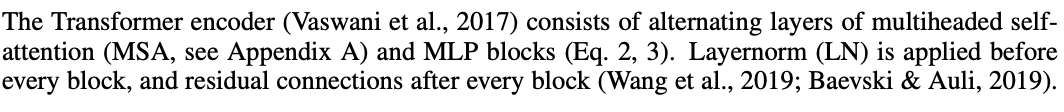

**Equation 4:** 

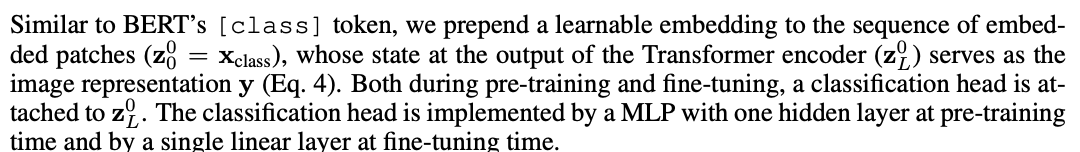










#### Table 1

![](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-table-1.png?raw=true)
